# Plot DA3 vs KITTI Odometry Trajectory

This notebook loads `da3_kitti_odom.py` outputs, connects the batch-local DA3 `extrinsics` into a full-sequence pseudo pose trajectory, aligns that connected full sequence to KITTI odometry GT poses in one step, and plots the DA3 and GT trajectories together.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from depth_anything_3.utils.geometry import affine_inverse_np
from depth_anything_3.utils.pose_align import align_poses_umeyama

DATASET_ROOT = Path("/home/kobayashi/dataset/kitti_odom/dataset")
RESULTS_ROOT = Path("/home/kobayashi/dataset/kitti_odom/depth_anything3_num_img150_long_edge730")
SEQUENCE_ID = "10"
CAMERA = "image_2"
NUM_IMAGES = RESULTS_ROOT.name.split("_")[-3].replace("img", "")
LONG_EDGE = RESULTS_ROOT.name.split("_")[-1].replace("edge", "")
NUM_IMAGES = int(NUM_IMAGES)
LONG_EDGE = int(LONG_EDGE)

In [2]:
def get_sorted_batch_paths(sequence_results_dir: Path) -> list[Path]:
    batch_paths = sorted(sequence_results_dir.glob("*.npz"), key=lambda path: int(path.stem))
    if not batch_paths:
        raise FileNotFoundError(f"No DA3 result files were found in {sequence_results_dir}")
    return batch_paths


def build_batch_ranges(num_images: int, window_size: int) -> list[tuple[int, int]]:
    if window_size <= 0:
        raise ValueError(f"window_size must be positive, but got {window_size}")
    if num_images <= 0:
        return []
    if num_images <= window_size:
        return [(0, num_images)]

    batch_ranges = []
    start = 0
    while start + window_size <= num_images:
        batch_ranges.append((start, start + window_size))
        start += window_size

    if num_images % window_size != 0:
        batch_ranges.append((num_images - window_size, num_images))

    return batch_ranges


def to_homogeneous_matrices(matrices: np.ndarray) -> np.ndarray:
    matrices = np.asarray(matrices, dtype=np.float64)
    if matrices.ndim != 3:
        raise ValueError(f"Expected matrices with 3 dimensions, got shape {matrices.shape}")
    if matrices.shape[-2:] == (4, 4):
        return matrices
    if matrices.shape[-2:] != (3, 4):
        raise ValueError(
            f"Expected matrices with shape (N, 3, 4) or (N, 4, 4), got {matrices.shape}"
        )

    homogeneous = np.repeat(np.eye(4, dtype=np.float64)[None, ...], matrices.shape[0], axis=0)
    homogeneous[:, :3, :4] = matrices
    return homogeneous


def load_kitti_gt_poses(dataset_root: Path, sequence_id: str) -> np.ndarray:
    gt_path = dataset_root / "poses" / f"{sequence_id}.txt"
    if not gt_path.exists():
        raise FileNotFoundError(f"GT pose file not found: {gt_path}")
    return np.loadtxt(gt_path, dtype=np.float64).reshape(-1, 3, 4)


def kitti_gt_trajectory_from_poses(gt_poses: np.ndarray) -> np.ndarray:
    return np.asarray(gt_poses, dtype=np.float64)[:, :3, 3].copy()


def kitti_gt_extrinsics_for_alignment(gt_poses: np.ndarray) -> np.ndarray:
    return affine_inverse_np(to_homogeneous_matrices(gt_poses))[:, :3, :4]


def trajectory_from_da3_extrinsics(extrinsics: np.ndarray) -> np.ndarray:
    poses = affine_inverse_np(to_homogeneous_matrices(extrinsics))
    return poses[:, :3, 3]


def connect_da3_batch_extrinsics(
    num_frames: int,
    batch_paths: list[Path],
    batch_ranges: list[tuple[int, int]],
    matrix_shape: tuple[int, int],
) -> tuple[np.ndarray, np.ndarray]:
    connected_poses = np.full((num_frames, 4, 4), np.nan, dtype=np.float64)

    for batch_idx, (batch_path, (start, end)) in enumerate(zip(batch_paths, batch_ranges)):
        with np.load(batch_path) as batch:
            pred_extrinsics = batch["extrinsics"].astype(np.float64)

        expected_batch_len = end - start
        if len(pred_extrinsics) != expected_batch_len:
            raise ValueError(
                f"{batch_path.name} has {len(pred_extrinsics)} poses, but expected {expected_batch_len}"
            )
        if pred_extrinsics.shape[1:] != matrix_shape:
            raise ValueError(
                f"{batch_path.name} has pose shape {pred_extrinsics.shape[1:]}, expected {matrix_shape}"
            )

        poses_local = affine_inverse_np(to_homogeneous_matrices(pred_extrinsics))
        if batch_idx == 0:
            batch_to_global = np.linalg.inv(poses_local[0])
        else:
            if np.isfinite(connected_poses[start]).all():
                anchor_pose = connected_poses[start]
            elif start > 0 and np.isfinite(connected_poses[start - 1]).all():
                anchor_pose = connected_poses[start - 1]
            else:
                raise RuntimeError(f"No anchor pose is available to connect {batch_path.name}")
            batch_to_global = anchor_pose @ np.linalg.inv(poses_local[0])

        poses_connected = batch_to_global @ poses_local

        # Keep earlier windows for overlaps and only fill unseen global frames.
        missing_mask = np.isnan(connected_poses[start:end]).all(axis=(1, 2))
        missing_indices = np.flatnonzero(missing_mask) + start
        connected_poses[missing_indices] = poses_connected[missing_mask]

    filled_mask = np.isfinite(connected_poses).all(axis=(1, 2))
    connected_extrinsics = affine_inverse_np(connected_poses)
    return connected_extrinsics, filled_mask


def align_da3_sequence_to_gt(gt_poses: np.ndarray, pred_extrinsics: np.ndarray) -> tuple[np.ndarray, float]:
    gt_extrinsics = kitti_gt_extrinsics_for_alignment(gt_poses)
    _, _, scale, aligned_extrinsics = align_poses_umeyama(
        gt_extrinsics,
        pred_extrinsics,
        return_aligned=True,
    )
    gt_traj = kitti_gt_trajectory_from_poses(gt_poses)
    pred_traj = trajectory_from_da3_extrinsics(aligned_extrinsics)
    pred_traj += gt_traj[0] - pred_traj[0]
    return pred_traj, float(scale)


In [3]:
sequence_image_dir = DATASET_ROOT / "sequences" / SEQUENCE_ID / CAMERA
sequence_results_dir = RESULTS_ROOT / SEQUENCE_ID

if not sequence_image_dir.exists():
    raise FileNotFoundError(f"Sequence image directory not found: {sequence_image_dir}")
if not sequence_results_dir.exists():
    raise FileNotFoundError(f"Sequence results directory not found: {sequence_results_dir}")

image_paths = sorted(sequence_image_dir.glob("*.png"))
if not image_paths:
    raise FileNotFoundError(f"No PNG images were found in {sequence_image_dir}")

gt_poses = load_kitti_gt_poses(DATASET_ROOT, SEQUENCE_ID)
if len(gt_poses) != len(image_paths):
    raise ValueError(
        f"GT frame count ({len(gt_poses)}) does not match image count ({len(image_paths)})"
    )

gt_traj_full = kitti_gt_trajectory_from_poses(gt_poses)

batch_paths = get_sorted_batch_paths(sequence_results_dir)
with np.load(batch_paths[0]) as first_batch:
    first_batch_extrinsics = first_batch["extrinsics"].astype(np.float64)

window_size = int(first_batch_extrinsics.shape[0])
matrix_shape = first_batch_extrinsics.shape[1:]

batch_ranges = build_batch_ranges(num_images=len(image_paths), window_size=window_size)
if len(batch_paths) != len(batch_ranges):
    raise ValueError(
        f"Found {len(batch_paths)} batch files, but expected {len(batch_ranges)} windows from the dataset"
    )

pred_extrinsics_full, filled_mask = connect_da3_batch_extrinsics(
    num_frames=len(image_paths),
    batch_paths=batch_paths,
    batch_ranges=batch_ranges,
    matrix_shape=matrix_shape,
)
if not filled_mask.any():
    raise RuntimeError("The connected DA3 extrinsics are empty")
if int(filled_mask.sum()) != len(gt_poses):
    raise AssertionError(
        f"The connected DA3 trajectory covers {int(filled_mask.sum())} frames, expected {len(gt_poses)}"
    )

pred_traj_full = np.full((len(image_paths), 3), np.nan, dtype=np.float64)
pred_traj_full[filled_mask], global_alignment_scale = align_da3_sequence_to_gt(
    gt_poses[filled_mask],
    pred_extrinsics_full[filled_mask],
)

first_valid_index = int(np.flatnonzero(filled_mask)[0])
if not np.allclose(pred_traj_full[first_valid_index], gt_traj_full[first_valid_index]):
    raise AssertionError("The first valid predicted point does not match the GT start point")

summary = {
    "Sequence ID": SEQUENCE_ID,
    "Camera": CAMERA,
    "GT frames": len(gt_poses),
    "DA3 batch files": len(batch_paths),
    "Window size": window_size,
    "Connected predicted frames": int(filled_mask.sum()),
    "First valid frame": first_valid_index,
    "Global alignment scale": global_alignment_scale,
}


In [4]:
for key, value in summary.items():
    print(f"{key}: {value}")


Sequence ID: 10
Camera: image_2
GT frames: 1201
DA3 batch files: 9
Window size: 150
Connected predicted frames: 1201
First valid frame: 0
Global alignment scale: 0.8702833802788962


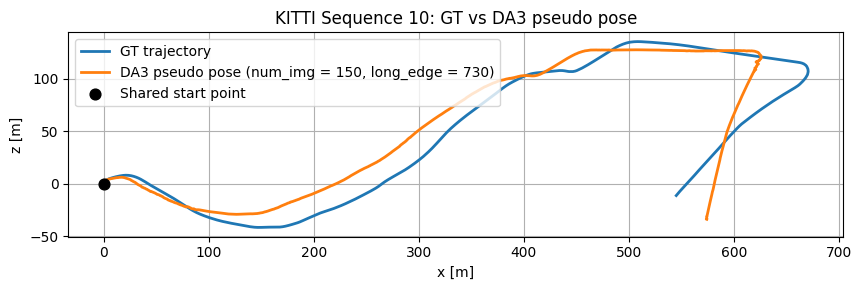

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(gt_traj_full[:, 0], gt_traj_full[:, 2], label="GT trajectory", linewidth=2, color="tab:blue")
ax.plot(
    pred_traj_full[filled_mask, 0],
    pred_traj_full[filled_mask, 2],
    label=f"DA3 pseudo pose (num_img = {NUM_IMAGES}, long_edge = {LONG_EDGE})",
    linewidth=2,
    color="tab:orange",
)
ax.scatter(
    gt_traj_full[first_valid_index, 0],
    gt_traj_full[first_valid_index, 2],
    color="black",
    s=60,
    label="Shared start point",
    zorder=3,
)
ax.set_title(
    f"KITTI Sequence {SEQUENCE_ID}: GT vs DA3 pseudo pose"
)
ax.set_xlabel("x [m]")
ax.set_ylabel("z [m]")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
ax.legend()
plt.show()
